# VeriGym vs. Gymnasium: how fast is discretization?

Both libraries can turn a continuous observation into bin numbers.
Gymnasium does it with `DiscretizeObservation`, VeriGym with `BinEdges`.

The discretizer only sees an array of numbers. Where the environment comes
from (classic control, Box2D, MuJoCo, ...) or if it represents an image does
not matter directly. What matters:

- **number of dimensions** `d` (the main factor),
- **data type** (float32, float64, int32, uint8).

We look at:

1. Time per observation on real environments, ordered by `d` (Figure 1).
2. How the time grows with `d` (Figure 2).
3. The effect of the data type: speed, and VeriGym's one-time compile cost
   (numba JIT) (Figure 3).
4. After how many calls that compile cost pays off, for any number of
   dimensions (Figure 4).

Set `QUICK = True` for a short test run.

In [2]:
import gc
import itertools
import json
import platform
import subprocess
import sys
import textwrap
from importlib.metadata import version
from time import perf_counter, perf_counter_ns

import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from gymnasium.spaces import Box
from gymnasium.wrappers import FlattenObservation, TransformObservation
from gymnasium.wrappers.transform_observation import DiscretizeObservation
from tqdm.auto import tqdm

from verigym.abstraction.discretization import generate_box_bins

QUICK = False

BINS = 10  # bins per dimension
SEED = 0
N_OBS = 500 if QUICK else 2_000  # recorded observations per environment
N_STEPS = 200 if QUICK else 1_000  # plain env.step() calls per environment
REPEATS = 3 if QUICK else 7  # repeats per timing
TARGET_S = 0.01 if QUICK else 0.05  # minimum length of one timed batch
MAX_DIM = 1_000 if QUICK else 100_000
DIMS = [m * 10**e for e in range(6) for m in (1, 2, 5) if m * 10**e <= MAX_DIM]  # 1, 2, 5, 10, ...
DTYPES = ["float32", "float64", "int32", "uint8"]
DTYPE_DIM = 64
COLD_REPEATS = 3 if QUICK else 5  # fresh processes per data type

COLORS = {"gymnasium": "#4C72B0", "verigym": "#DD8452"}
NAMES = {"gymnasium": "Gymnasium", "verigym": "VeriGym"}
LIGHT_GREY = "#a0a0a0"  # annotations (arrows, text boxes)
MARKERS = {"float32": "o", "float64": "s", "int32": "D", "uint8": "^"}  # one per data type

print(f"CPU:        {platform.processor() or platform.machine()} ({platform.platform()})")
print(f"Python:     {platform.python_version()}")
for pkg in ["numpy", "numba", "gymnasium", "verigym"]:
    print(f"{pkg + ':':<12}{version(pkg)}")

CPU:        arm (macOS-26.6.2-arm64-arm-64bit)
Python:     3.12.0
numpy:      2.5.2
numba:      0.67.0
gymnasium:  1.3.0
verigym:    0.1.0


## Environments

Gymnasium's discretization methods need finite bounds on every dimension.
Some environments (MuJoCo) have infinite bounds. For those we record some
observations first and set the smallest and largest seen values as bounds.

Gymnasium also only works on flat (1-D) observations, so for the image
environment (CarRacing) we flatten the image first on the Gymnasium side.

The environments are picked to cover a wide range of state-/observation
dimensions `d`, including the data types float32, float64 and uint8 (an RGB
image). They are listed from small to large `d`.

In [3]:
ENVS = [  # env id, with d and data type of its observation
    "MountainCarContinuous-v0",  # 2, float32
    "Pendulum-v1",  # 3, float32
    "Acrobot-v1",  # 6, float32
    "LunarLander-v3",  # 8, float32
    "Hopper-v5",  # 11, float64
    "HalfCheetah-v5",  # 17, float64
    "BipedalWalker-v3",  # 24, float32
    "Ant-v5",  # 105, float64
    "Humanoid-v5",  # 348, float64
    "CarRacing-v3",  # 96x96x3 = 27648, uint8
]
if QUICK:
    ENVS = ["Pendulum-v1", "HalfCheetah-v5", "CarRacing-v3"]


def collect_obs(env, n, seed=SEED):
    """Run random actions and record `n` observations."""
    env.action_space.seed(seed)
    obs, _ = env.reset(seed=seed)
    out = [obs]
    while len(out) < n:
        obs, _, terminated, truncated, _ = env.step(env.action_space.sample())
        if terminated or truncated:
            obs, _ = env.reset()
        out.append(obs)
    return np.asarray(out)


def make_bounded_env(env_id):
    """Make the env and replace infinite bounds with the seen min/max values.

    Returns the env and the recorded observations.
    """
    env = gym.make(env_id)
    obs = collect_obs(env, N_OBS)
    space = env.observation_space
    if not (np.all(np.isfinite(space.low)) and np.all(np.isfinite(space.high))):
        low, high = obs.min(axis=0), obs.max(axis=0)
        margin = 1e-6 + 1e-3 * (high - low)
        # Not `ReplaceInfObservation`: it builds `Box(low, high)` without the
        # dtype, which would turn the float64 MuJoCo spaces into float32.
        bounded = Box(low - margin, high + margin, dtype=space.dtype)
        env = TransformObservation(env, lambda o: o, bounded)
    return env, obs


def gym_discretizer(env, bins):
    """Gymnasium wrapper; image spaces are flattened first."""
    if len(env.observation_space.shape) > 1:
        env = FlattenObservation(env)
    return DiscretizeObservation(env, bins=bins, multidiscrete=True)


class BoxEnv(gym.Env):
    """Tiny env that only exists to hold an observation space."""

    def __init__(self, space):
        self.observation_space = space
        self.action_space = gym.spaces.Discrete(1)


def make_space(d, dtype):
    """A made-up `Box` space with `d` dimensions; ints use 0..255."""
    if np.dtype(dtype).kind in "iu":
        return Box(0, 255, (d,), dtype=dtype)
    return Box(-1.0, 1.0, (d,), dtype=dtype)

## How we measure time

One call takes only a few microseconds, which is close to the cost of
reading the clock itself. So we do not time single calls. Instead we time a
batch of multiple calls and divide by the batch size. The batch is made
bigger until it runs for at least `TARGET_S` seconds. We repeat this
`REPEATS` many times and keep the median (middle value) and the 25%/75%
values (IQR range).

Before timing, each function is called once, so VeriGym's compile step is
not part of these numbers. We measure the compile step on its own later.

In [4]:
def _run_batch(fn, obs_list, k):
    calls = itertools.islice(itertools.cycle(obs_list), k)
    gc.disable()
    start = perf_counter()
    for o in calls:
        fn(o)
    elapsed = perf_counter() - start
    gc.enable()
    return elapsed


def time_per_call(fn, obs):
    """Return the per-call times in microseconds, one per repeat."""
    obs_list = list(obs)
    fn(obs_list[0])  # warm-up (compiles numba code)
    k = 1
    while _run_batch(fn, obs_list, k) < TARGET_S:
        k *= 2
    return np.array([_run_batch(fn, obs_list, k) / k for _ in range(REPEATS)]) * 1e6


def summarize(times):
    q25, med, q75 = np.percentile(times, [25, 50, 75])
    return {"median_us": med, "q25_us": q25, "q75_us": q75}

## 1. Time per observation on real environments

Both libraries return one bin number per dimension (a `MultiDiscrete`
sample). We also check that both libraries give the same bins.

To see whether the discretization time matters in practice, we also time a
plain `env.step()` (without any discretizer) for each environment. Each step
is timed on its own, which is fine because a step is much slower than reading
the clock. Resets are not timed. We keep the median.

In [5]:
def median_step_us(env):
    """Median time of one plain `env.step()` in µs."""
    env.action_space.seed(SEED)
    env.reset(seed=SEED)
    times = []
    for _ in range(N_STEPS):
        action = env.action_space.sample()
        start = perf_counter_ns()
        _, _, terminated, truncated, _ = env.step(action)
        times.append(perf_counter_ns() - start)
        if terminated or truncated:
            env.reset()
    return np.median(times) / 1e3


env_rows = []  # one row per (env, library)

for env_id in tqdm(ENVS, desc="Environments"):
    env, obs = make_bounded_env(env_id)
    space = env.observation_space
    bin_edges = generate_box_bins(space, np.linspace, BINS)
    gym_wrap = gym_discretizer(env, BINS)
    flat_obs = obs.reshape(len(obs), -1)

    # Do both libraries put each value in the same bin?
    gym_idx = np.array([gym_wrap.observation(o) for o in flat_obs])
    vg_idx = np.array([bin_edges.orig_to_idx(o).ravel() for o in obs])

    base = {
        "env": env_id,
        "d": int(np.prod(space.shape)),
        "dtype": str(space.dtype),
        "agreement": np.mean(gym_idx == vg_idx),
        "step_us": median_step_us(env),
    }
    env_rows.append(
        {**base, "lib": "gymnasium",
         **summarize(time_per_call(gym_wrap.observation, flat_obs))}
    )
    env_rows.append(
        {**base, "lib": "verigym", **summarize(time_per_call(bin_edges.orig_to_idx, obs))}
    )

print(f"{'env':<26}{'d':>6}{'same bins':>11}{'env.step()':>12}"
      f"{'Gymnasium':>12}{'VeriGym':>10}   (discretization as % of env.step())")
gym_by_env = {r["env"]: r for r in env_rows if r["lib"] == "gymnasium"}
for r in env_rows:
    if r["lib"] == "verigym":
        g = gym_by_env[r["env"]]
        print(f"{r['env']:<26}{r['d']:>6}{r['agreement']:>11.2%}{r['step_us']:>9.1f} µs"
              f"{g['median_us'] / g['step_us']:>11.1%}{r['median_us'] / r['step_us']:>10.1%}")

Environments:   0%|          | 0/10 [00:00<?, ?it/s]

env                            d  same bins  env.step()   Gymnasium   VeriGym   (discretization as % of env.step())
MountainCarContinuous-v0       2    100.00%      1.9 µs     329.9%     63.7%
Pendulum-v1                    3    100.00%      8.5 µs      95.6%     13.1%
Acrobot-v1                     6    100.00%     27.4 µs      52.1%      4.2%
LunarLander-v3                 8    100.00%     24.6 µs      84.3%      5.0%
Hopper-v5                     11    100.00%     83.4 µs      24.6%      1.6%
HalfCheetah-v5                17    100.00%     33.5 µs      92.6%      4.9%
BipedalWalker-v3              24    100.00%     90.6 µs      62.4%      1.6%
Ant-v5                       105    100.00%    210.3 µs      96.3%      1.1%
Humanoid-v5                  348    100.00%    173.4 µs     361.6%      3.8%
CarRacing-v3               27648    100.00%   4276.2 µs    1052.9%      4.9%


## 2. How time grows with the number of dimensions

Here we use a synthetic (made-up) space `Box(-1, 1, (d,))` with random float32
values and 10 bins per dimension, so the only thing that changes is the number
of dimensions `d`. We go from `d = 1` up to `d = 10^5` (`10^3` with `QUICK`),
which also covers the largest real environment (CarRacing, `d = 27648`).

In [6]:
def bench_synthetic(d, bins, dtype="float32"):
    space = make_space(d, dtype)
    space.seed(SEED)
    obs = np.array([space.sample() for _ in range(min(N_OBS, 200))])
    gym_wrap = gym_discretizer(BoxEnv(space), bins)
    bin_edges = generate_box_bins(space, np.linspace, bins)
    return {
        "gymnasium": summarize(time_per_call(gym_wrap.observation, obs)),
        "verigym": summarize(time_per_call(bin_edges.orig_to_idx, obs)),
    }


dim_rows = [{"d": d, **bench_synthetic(d, BINS)} for d in tqdm(DIMS, desc="Dimensions")]

Dimensions:   0%|          | 0/16 [00:00<?, ?it/s]

## 3. Data type: speed and compile cost

Here the size stays fixed (`d = 64`, 10 bins) and only the data type changes.
So any difference comes from the data type alone.

**Warm speed:** time per observation once everything is ready.

**Compile cost:** VeriGym's core loop is compiled by numba the first time it
is called. numba compiles a new version for **each data type**, so each one
pays this cost once. The compiled code is not kept between Python sessions,
so every new process pays it again. To see the real cost we start a fresh
Python process for each data type and time the first and second call there.
We do this `COLD_REPEATS` times per data type and keep the median and IQR.

From that we get the **break-even point**: how many calls it takes before
VeriGym has made up for the compile time.

In [7]:
dtype_rows = [
    {"dtype": dt, **bench_synthetic(DTYPE_DIM, BINS, dt)}
    for dt in tqdm(DTYPES, desc="Data types")
]
for r in dtype_rows:
    print(f"{r['dtype']:<8} Gymnasium {r['gymnasium']['median_us']:7.2f} µs, "
          f"VeriGym {r['verigym']['median_us']:6.2f} µs")

Data types:   0%|          | 0/4 [00:00<?, ?it/s]

float32  Gymnasium  124.05 µs, VeriGym   1.67 µs
float64  Gymnasium  110.48 µs, VeriGym   1.65 µs
int32    Gymnasium  110.73 µs, VeriGym   1.66 µs
uint8    Gymnasium  107.40 µs, VeriGym   1.62 µs


In [8]:
COLD_SCRIPT = textwrap.dedent(
    """
    import json, sys
    from time import perf_counter
    import numpy as np
    from gymnasium.spaces import Box
    from verigym.abstraction.discretization import generate_box_bins

    dtype = np.dtype(sys.argv[1])
    high = 255 if dtype.kind in "iu" else 1
    space = Box(0, high, (16,), dtype=dtype)
    bin_edges = generate_box_bins(space, np.linspace, 10)
    x = space.sample()
    t0 = perf_counter(); bin_edges.orig_to_idx(x); t1 = perf_counter()
    bin_edges.orig_to_idx(x); t2 = perf_counter()
    print(json.dumps({"first_s": t1 - t0, "second_s": t2 - t1}))
    """
)


def cold_start(dtype):
    out = subprocess.run(
        [sys.executable, "-c", COLD_SCRIPT, dtype],
        capture_output=True, text=True, check=True,
    )
    return json.loads(out.stdout.strip().splitlines()[-1])


# Take turns between the data types, so that no type always runs first.
cold = {dt: [] for dt in DTYPES}
for _ in tqdm(range(COLD_REPEATS), desc="Compile (fresh process)"):
    for dt in DTYPES:
        cold[dt].append(cold_start(dt))

jit = {}
for dt, runs in cold.items():
    q25, med, q75 = np.percentile([r["first_s"] for r in runs], [25, 50, 75])
    second = np.median([r["second_s"] for r in runs])
    jit[dt] = {"first_s": med, "first_q25_s": q25, "first_q75_s": q75, "second_s": second}
    print(f"{dt:<8} first call {med * 1e3:6.1f} ms (IQR {q25 * 1e3:.1f}-{q75 * 1e3:.1f}), "
          f"second call {second * 1e6:5.1f} µs")


def break_even(env_id):
    """Number of calls after which VeriGym (incl. compile) is faster in total."""
    rows = {r["lib"]: r for r in env_rows if r["env"] == env_id}
    saved_per_call = (rows["gymnasium"]["median_us"] - rows["verigym"]["median_us"]) * 1e-6
    if saved_per_call <= 0:
        return np.inf
    return jit[rows["verigym"]["dtype"]]["first_s"] / saved_per_call

Compile (fresh process):   0%|          | 0/5 [00:00<?, ?it/s]

float32  first call  505.8 ms (IQR 505.2-530.8), second call  12.0 µs
float64  first call  507.0 ms (IQR 498.8-507.6), second call  12.7 µs
int32    first call  510.6 ms (IQR 503.7-517.2), second call  12.5 µs
uint8    first call  510.1 ms (IQR 509.8-526.6), second call  12.5 µs


## Figures

In [9]:
def lib_rows(lib):
    return [r for r in env_rows if r["lib"] == lib]


def err(rows):
    med = np.array([r["median_us"] for r in rows])
    return med, [med - [r["q25_us"] for r in rows], [r["q75_us"] for r in rows] - med]

### Figure 1a: time per observation for each environment

Lower is better. The y axis is logarithmic. Environments are sorted by `d`.
The number above each pair says how many times faster VeriGym is.

The whiskers show the IQR over the repeats. They are mostly too small to
see, which means the measurement is stable.

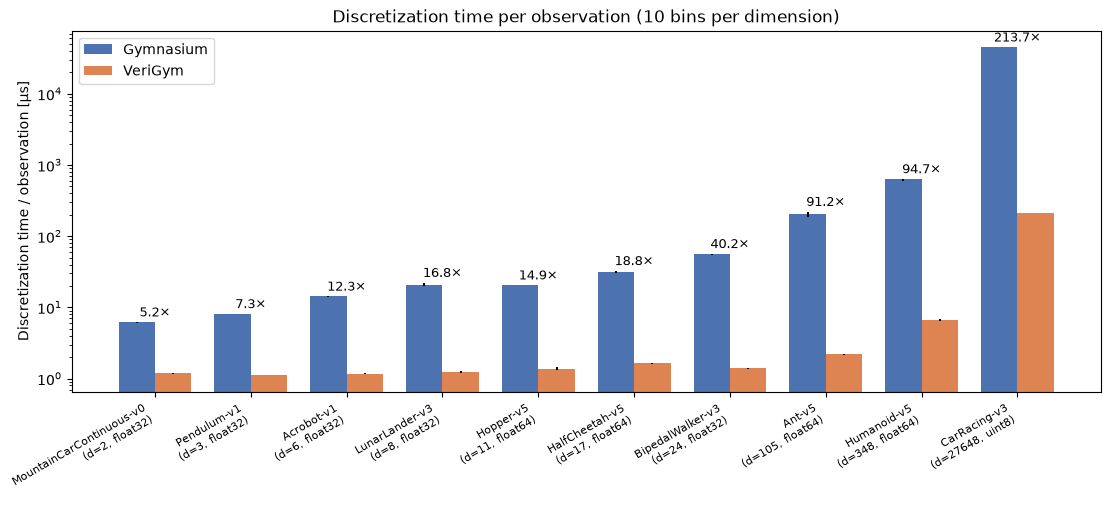

In [10]:
gym_r, vg_r = lib_rows("gymnasium"), lib_rows("verigym")
order = np.argsort([r["d"] for r in gym_r])
gym_r, vg_r = [gym_r[i] for i in order], [vg_r[i] for i in order]
x, width = np.arange(len(gym_r)), 0.38

fig, ax = plt.subplots(num="Figure 1a: Time per observation", figsize=(11, 5),
                       constrained_layout=True)
for offset, lib, rows in [(-width / 2, "gymnasium", gym_r), (width / 2, "verigym", vg_r)]:
    med, yerr = err(rows)
    ax.bar(x + offset, med, width, yerr=yerr, color=COLORS[lib], label=NAMES[lib])
for i, (g, v) in enumerate(zip(gym_r, vg_r)):
    top = max(g["q75_us"], v["q75_us"])
    ax.annotate(f"{g['median_us'] / v['median_us']:.1f}×", (i, top), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_xticks(x, [f"{r['env']}\n(d={r['d']}, {r['dtype']})" for r in gym_r],
              rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Discretization time / observation [µs]")
ax.set_title(f"Discretization time per observation ({BINS} bins per dimension)")
ax.legend()
plt.show()

### Figure 1b: discretization time compared to `env.step()`

The discretization time as a percentage of one plain `env.step()` of the same
environment. Each dot is one environment, and the violin shows how these
values are spread over all environments. The y axis is logarithmic. At the
dashed 100% line, discretizing takes as long as the step itself.

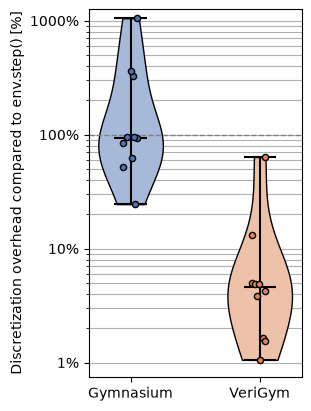

In [22]:
from matplotlib.colors import to_rgb


def blend_white(color, amount=0.5):
    """Mix `color` with white; looks like alpha=`amount` but is opaque."""
    return tuple(amount * c + (1 - amount) * 1.0 for c in to_rgb(color))


fig, ax_v = plt.subplots(
    num="Figure 1b: Compared to env.step()",
    figsize=(3, 4),
    constrained_layout=True,
)

# Right: discretization time as % of one env.step(). The violins are drawn on
# log10 of the values, so that their shape matches the log axis.
rng = np.random.default_rng(SEED)
log_share = {
    lib: np.log10([r["median_us"] / r["step_us"] * 100 for r in rows])
    for lib, rows in [("gymnasium", gym_r), ("verigym", vg_r)]
}

parts = ax_v.violinplot(list(log_share.values()), positions=[0, 1], showmedians=True)

for body, lib in zip(parts["bodies"], log_share):
    # Opaque light color (instead of alpha), so the grid does not shine through.
    body.set(facecolor=blend_white(COLORS[lib]), edgecolor="black", alpha=1)

for key in ["cmins", "cmaxes", "cbars", "cmedians"]:
    parts[key].set_color("black")

for pos, (lib, values) in enumerate(log_share.items()):
    jitter = rng.uniform(-0.06, 0.06, len(values))
    ax_v.scatter(
        pos + jitter,
        values,
        color=COLORS[lib],
        edgecolor="black",
        s=20,
        zorder=3,
    )

ax_v.axhline(2, color="grey", ls="--", lw=1)  # log10(100%)

all_values = np.concatenate(list(log_share.values()))
ticks = np.arange(np.floor(all_values.min()), np.ceil(all_values.max()) + 1)

ax_v.set_yticks(ticks, [f"{10**t:g}%" for t in ticks])
ax_v.set_yticks(
    [t + np.log10(m) for t in ticks for m in range(2, 10)],
    minor=True,
)

ax_v.set_axisbelow(True)
ax_v.grid(axis="y", which="both")

ax_v.set_xticks([0, 1], [NAMES[lib] for lib in log_share])
ax_v.set_ylabel("Discretization overhead compared to env.step() [%]")
ax_v.set_ylim(None, 3.1)
fig.savefig("discretization_overhead_env_step.pdf", bbox_inches='tight')

plt.show()


### Figure 2: how time grows with the number of dimensions

Both axes are logarithmic. The lines are the synthetic float32 `Box` spaces,
the markers are the real environments from Figure 1. The marker shape shows
the data type of the environment. The environment name is written next to the
Gymnasium marker; the VeriGym marker of the same environment is straight
below it. The bands show the IQR.

If the markers sit on the lines, the number of dimensions alone explains the
time. Small offsets are expected: Gymnasium is about 10% slower on float32
than on float64 (see Figure 3), and two separate measurements of the same
thing differ by a few percent from run to run.

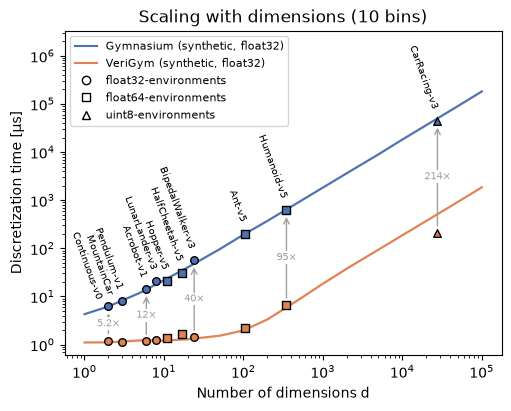

In [21]:
from matplotlib.lines import Line2D

LABEL_ROTATION = -70  # angle of the environment names, in degrees

fig, ax_d = plt.subplots(num="Figure 2: Scaling with dimensions", figsize=(5, 4),
                        constrained_layout=True)
handles = []
for lib in ["gymnasium", "verigym"]:
    med = np.array([r[lib]["median_us"] for r in dim_rows])
    (line,) = ax_d.plot(DIMS, med, "-", color=COLORS[lib],
                        label=f"{NAMES[lib]} (synthetic, float32)")
    handles.append(line)
    ax_d.fill_between(DIMS, [r[lib]["q25_us"] for r in dim_rows],
                      [r[lib]["q75_us"] for r in dim_rows], color=COLORS[lib], alpha=0.2)
    for r in lib_rows(lib):
        ax_d.scatter(r["d"], r["median_us"], marker=MARKERS[r["dtype"]],
                     color=COLORS[lib], edgecolor="black", zorder=3, s=30)
for r in lib_rows("gymnasium"):
    env_name = r["env"]
    xytext = (2,10)
    if "MountainCar" in env_name:
        env_name = "MountainCar\nContinuous-v0"
        xytext = (6,10)
    ax_d.annotate(env_name, (r["d"], r["median_us"]), xytext=xytext,
                  textcoords="offset points", fontsize=7, rotation=LABEL_ROTATION,
                  rotation_mode="anchor", ha="right", va="top")

# Arrows from Gymnasium down to VeriGym with the speedup in the middle.
SPEEDUP_ENVS = ["MountainCarContinuous-v0", "Acrobot-v1", "BipedalWalker-v3",
                "Humanoid-v5", "CarRacing-v3"]
by_env = {(r["env"], r["lib"]): r for r in env_rows}
for env_id in SPEEDUP_ENVS:
    if (env_id, "gymnasium") not in by_env:
        continue
    g, v = by_env[(env_id, "gymnasium")], by_env[(env_id, "verigym")]
    d, top, bottom = g["d"], g["median_us"], v["median_us"]
    ax_d.annotate("", xy=(d, bottom), xytext=(d, top), zorder=1,
                  arrowprops={"arrowstyle": "<-", "color": LIGHT_GREY, "lw": 1,
                              "shrinkA": 5, "shrinkB": 5})
    speedup = top / bottom
    # Middle on a log axis = geometric mean. The white box hides the arrow
    # line behind the text.
    ax_d.text(d, np.sqrt(top * bottom), f"{speedup:.0f}×" if speedup >= 10 else f"{speedup:.1f}×",
              ha="center", va="center", fontsize=7, color=LIGHT_GREY, zorder=2,
              bbox={"boxstyle": "square,pad=0.15", "facecolor": "white", "edgecolor": "none"})

# One legend entry per data type that occurs, shown as an empty marker.
for dtype in dict.fromkeys(r["dtype"] for r in env_rows):
    handles.append(Line2D([], [], ls="", marker=MARKERS[dtype], markerfacecolor="white",
                          markeredgecolor="black", label=f"{dtype}-environments"))
ax_d.set(xscale="log", yscale="log", xlabel="Number of dimensions d",
         ylabel="Discretization time [µs]", title=f"Scaling with dimensions ({BINS} bins)")
ax_d.set_ylim(top=ax_d.get_ylim()[1] * 10)  # room for the names on top
ax_d.legend(handles=handles, fontsize=8)
fig.savefig("discretization_times.pdf", bbox_inches='tight')
plt.show()

### Figure 3: effect of the data type

Left: time per observation (`d = 64`, 10 bins), log scale. Right: VeriGym's
one-time compile cost per data type, measured in a fresh Python process.
Whiskers show the IQR.

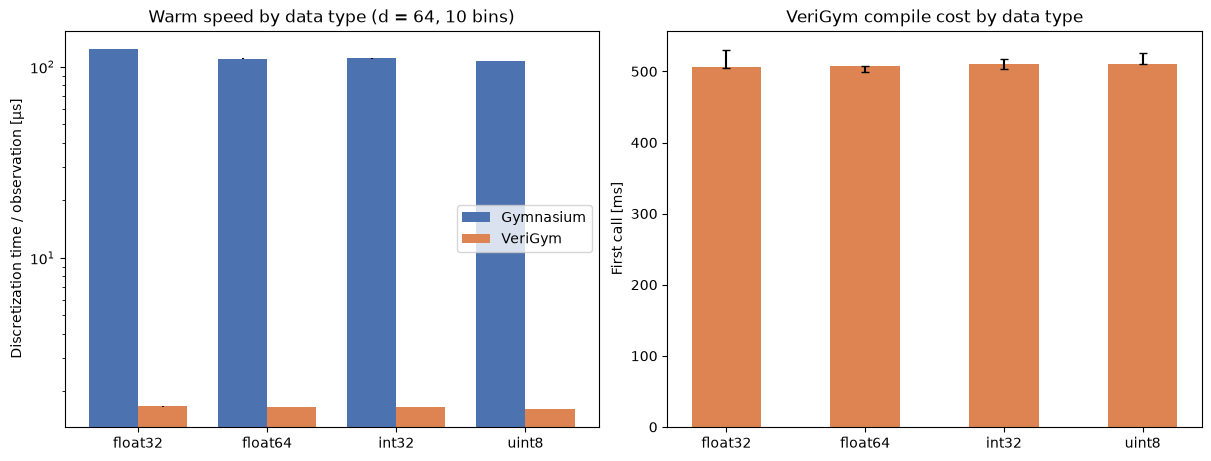

In [13]:
x = np.arange(len(DTYPES))
fig, (ax_t, ax_c) = plt.subplots(1, 2, num="Figure 3: Data type", figsize=(12, 4.5),
                                constrained_layout=True)
for offset, lib in [(-width / 2, "gymnasium"), (width / 2, "verigym")]:
    rows = [r[lib] for r in dtype_rows]
    med, yerr = err(rows)
    ax_t.bar(x + offset, med, width, yerr=yerr, color=COLORS[lib], label=NAMES[lib])
ax_t.set_yscale("log")
ax_t.set_xticks(x, DTYPES)
ax_t.set(ylabel="Discretization time / observation [µs]",
         title=f"Warm speed by data type (d = {DTYPE_DIM}, {BINS} bins)")
ax_t.legend(loc="center right")

med = np.array([jit[dt]["first_s"] for dt in DTYPES]) * 1e3
low = med - [jit[dt]["first_q25_s"] * 1e3 for dt in DTYPES]
high = [jit[dt]["first_q75_s"] * 1e3 for dt in DTYPES] - med
ax_c.bar(x, med, 0.5, yerr=[low, high], capsize=3, color=COLORS["verigym"])
ax_c.set_xticks(x, DTYPES)
ax_c.set(ylabel="First call [ms]", title="VeriGym compile cost by data type")
plt.show()

### Figure 4: when does the compile cost pay off?

VeriGym pays its compile time once, then saves time on every call. The
**break-even point** is the number of calls after which VeriGym is faster in
total:

`break-even = compile time / (Gymnasium time per call - VeriGym time per call)`

The time saved per call grows with the number of dimensions `d`, so the
break-even point drops with `d`. Both axes are logarithmic.

- The line uses the synthetic float32 `Box` spaces from Figure 2.
- Each marker is one real environment from Figure 1, using the compile time of
  its own data type. The marker shape shows the data type.
- The dashed lines are rough guides: about one episode (1,000 steps) and a
  short training run (10⁶ steps). Left of a line, VeriGym has paid off within
  that many steps.

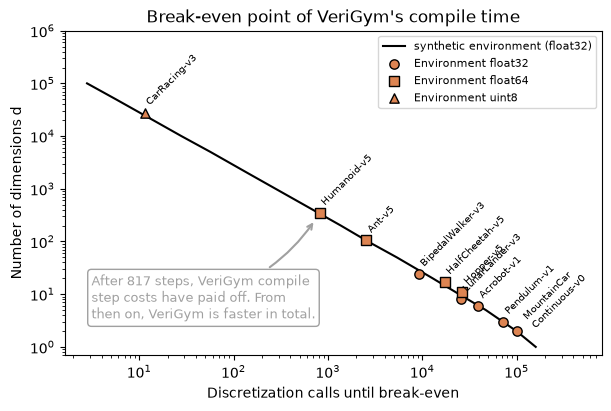

In [23]:
LABEL_ROTATION = 45  # angle of the environment names, in degrees

fig, ax = plt.subplots(num="Figure 4: Compile cost break-even", figsize=(6, 4),
                       constrained_layout=True)

# Line: synthetic float32 spaces of every size from Figure 2.
saved_s = np.array([r["gymnasium"]["median_us"] - r["verigym"]["median_us"]
                    for r in dim_rows]) * 1e-6
dims = np.array(DIMS)
ok = saved_s > 0  # where VeriGym is not faster, it never pays off
ax.plot(jit["float32"]["first_s"] / saved_s[ok], dims[ok], "-", color="black",
        label="synthetic environment (float32)")

# Markers: real environments, each with the compile time of its data type.
for dtype in dict.fromkeys(r["dtype"] for r in vg_r):
    rows = [r for r in vg_r if r["dtype"] == dtype]
    ax.scatter([break_even(r["env"]) for r in rows], [r["d"] for r in rows],
               marker=MARKERS[dtype], color=COLORS["verigym"], edgecolor="black",
               s=45, zorder=3, label=f"Environment {dtype}")
for r in vg_r:
    name = r["env"]
    xytext = (5, 4)
    if "MountainCar" in name:
        xytext = (15,0)
        name = "MountainCar\nContinuous-v0"
    ax.annotate(name, (break_even(r["env"]), r["d"]), xytext=xytext,
                textcoords="offset points", fontsize=7, rotation=LABEL_ROTATION,
                rotation_mode="anchor", ha="left", va="bottom")

# for steps, text in [(1e3, "≈ 1 episode (1,000 steps)"),
#                     (1e6, "≈ short training run (10⁶ steps)")]:
#     ax.axvline(steps, color="grey", ls="--", lw=1)
#     ax.annotate(text, (steps, 1), xytext=(-3, 4), textcoords="offset points",
#                 fontsize=8, color="grey", rotation=90, ha="right", va="bottom")

ax.set(xscale="log", yscale="log", xlabel="Discretization calls until break-even",
       ylabel="Number of dimensions d",
       title="Break-even point of VeriGym's compile time")
# Set the y range after switching to log scale; the extra room on top keeps
# the environment names inside the plot.
ax.set_ylim(0.7, max(max(DIMS), max(r["d"] for r in vg_r)) * 10)
ax.set_xlim(None, max(jit["float32"]["first_s"] / saved_s[ok])*5)

# Text box with an arrow to one example environment.
NOTE_ENV = "Humanoid-v5"
if NOTE_ENV in ENVS:
    r = next(r for r in vg_r if r["env"] == NOTE_ENV)
    n_star = break_even(NOTE_ENV)
    ax.annotate(
        f"After {n_star:,.0f} steps, VeriGym compile\nstep costs have paid off. "
        f"From\nthen on, VeriGym is faster in total.",
        xy=(n_star, r["d"]), xytext=(0.05, 0.10), textcoords="axes fraction",
        ha="left", va="bottom", multialignment="left", fontsize=9, color=LIGHT_GREY,
        bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": LIGHT_GREY},
        arrowprops={"arrowstyle": "->", "color": LIGHT_GREY, "lw": 1.5,
                    "connectionstyle": "arc3,rad=0.2",  # slightly bent
                    "shrinkB": 8},  # gap between arrowhead and marker
    )

ax.legend(fontsize=8, loc="upper right")
fig.savefig("break_even_steps.pdf", bbox_inches='tight')

plt.show()